#  UNIT 5 EXERCISE - Skip-gram (SGNS) Notebook 
LIBUNA, D. | CCS249 | 04/10//2026


## 1) Environment Setup and Reproducibility

In [1]:
# Optional package install (uncomment if needed in a fresh kernel)
# import sys
# !{sys.executable} -m pip install requests beautifulsoup4 nltk gensim scikit-learn scipy

import random
import numpy as np

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Seeds set to {RANDOM_SEED}")

Seeds set to 42


## 2) Imports and Global Configuration

In [2]:
import re
import json
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

WIKI_URL = "https://en.wikipedia.org/wiki/Gundam"
RANDOM_SEED = 42

## 3) NLTK Resource Check/Download

In [3]:
def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

ensure_nltk()

## 4) Wikipedia Fetch Utility

In [4]:
def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-Gundam-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []
    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)
    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

## 5) Text Preprocessing Pipeline

In [5]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)
    processed = []

    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)
        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

## 6) Corpus Statistics Utility

In [6]:
def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

# Quick preview run for this section
raw_text_preview = fetch_wikipedia_article(WIKI_URL)
sentences_preview = preprocess_text(raw_text_preview)
stats_preview = corpus_stats(sentences_preview)
print(stats_preview)

{'num_sentences': 260, 'num_tokens': 3952, 'vocab_size': 1481}


## 7) SGNS (Skip-gram Negative Sampling) Training Function

In [7]:
def train_sgns(sentences: List[List[str]]) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

model_preview = train_sgns(sentences_preview)
print("vector_size:", model_preview.vector_size)
print("window:", model_preview.window)
print("vocab size:", len(model_preview.wv))

vector_size: 100
window: 5
vocab size: 1481


## 8) Vector Utilities (Vocabulary Check and Cosine Similarity)

In [8]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

## 9) Evaluation Functions (Relatedness and Analogies)

In [9]:
def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    covered = []
    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }


def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit,
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details,
    }

## 10) Nearest-Neighbor Probing Utility

In [10]:
def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

probe_words = [
    "gundam", "mobile", "suit", "amuro", "zeon",
    "anime", "series", "film", "gunpla", "battle",
]
print_top_neighbors(model_preview, probe_words, topn=8)


=== Nearest Neighbors ===

gundam:
  cover                0.4187
  suit                 0.4111
  nt                   0.4034
  rock                 0.3871
  extreme              0.3743
  ray                  0.3708
  opens                0.3651
  amuro                0.3602

mobile:
  suit                 0.7686
  frog                 0.5595
  my-hime              0.5378
  shipp                0.5349
  onmy                 0.5339
  taisenki             0.5173
  wild                 0.5070
  notable              0.5029

suit:
  mobile               0.7686
  frog                 0.5811
  kirill               0.5742
  doug                 0.5690
  shipp                0.5647
  dirty                0.5646
  notable              0.5640
  entries              0.5598

amuro:
  ray                  0.9945
  aznable              0.9254
  music                0.9010
  char                 0.8614
  heero                0.7998
  zz                   0.7937
  victory              0.7856
  shipp   

## 11) Main Execution Cell (Data Fetch → Train → Evaluate)

In [14]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Fallback defaults so this cell runs even if Section 12 has not been executed yet.
if "relatedness_test" not in globals():
    relatedness_test = [
        ("gundam", "suit", 0.92),
        ("gundam", "amuro", 0.86),
        ("mobile", "suit", 0.94),
        ("anime", "series", 0.88),
        ("film", "movie", 0.90),
        ("robot", "mecha", 0.95),
        ("war", "battle", 0.80),
        ("gunpla", "model", 0.84),
        ("gundam", "kitchen", 0.05),
        ("anime", "tractor", 0.02),
        ("battle", "pilot", 0.40),
        ("franchise", "series", 0.78),
    ]

if "analogy_test" not in globals():
    analogy_test = [
        ("movie", "film", "tv", "series"),
        ("mobile", "suit", "robot", "mecha"),
        ("anime", "series", "movie", "film"),
        ("war", "battle", "pilot", "cockpit"),
    ]

if "check_pairs" not in globals():
    check_pairs = [
        ("gundam", "suit"),
        ("gundam", "amuro"),
        ("mobile", "suit"),
        ("robot", "mecha"),
        ("gundam", "kitchen"),
    ]

print("Downloading Wikipedia article...")
raw_text = fetch_wikipedia_article(WIKI_URL)

print("Preprocessing text...")
sentences = preprocess_text(raw_text)
stats = corpus_stats(sentences)

print("\n=== Corpus Stats ===")
for k, v in stats.items():
    print(f"{k}: {v}")

print("\nTraining Skip-gram with Negative Sampling...")
model = train_sgns(sentences)

print("\nVocabulary size learned:", len(model.wv))
print_top_neighbors(model, probe_words, topn=8)

rel_results = evaluate_relatedness(model, relatedness_test)
print("\n=== Relatedness Test Set ===")
print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
for w1, w2, gold, pred in rel_results["covered_items"]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

analogy_results = evaluate_analogies(model, analogy_test)
print("\n=== Analogy Test Set ===")
print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
for item in analogy_results["details"]:
    print(json.dumps(item, ensure_ascii=False))

print("\n=== Direct Similarity Checks ===")
for w1, w2 in check_pairs:
    if has_word(model, w1) and has_word(model, w2):
        print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

Preprocessing text...

=== Corpus Stats ===
num_sentences: 260
num_tokens: 3952
vocab_size: 1481

Training Skip-gram with Negative Sampling...

Vocabulary size learned: 1481

=== Nearest Neighbors ===

gundam:
  cover                0.4187
  suit                 0.4111
  nt                   0.4034
  rock                 0.3871
  extreme              0.3743
  ray                  0.3708
  opens                0.3651
  amuro                0.3602

mobile:
  suit                 0.7686
  frog                 0.5595
  my-hime              0.5378
  shipp                0.5349
  onmy                 0.5339
  taisenki             0.5173
  wild                 0.5070
  notable              0.5029

suit:
  mobile               0.7686
  frog                 0.5811
  kirill               0.5742
  doug                 0.5690
  shipp                0.5647
  dirty                0.5646
  notable              0.5640
  entries              0.5598

amuro:
  ray                  0.9945
  aznable       

## 12) Custom Adjustments

In [11]:
# Editable relatedness test set
relatedness_test = [
    ("gundam", "suit", 0.92),
    ("gundam", "amuro", 0.86),
    ("mobile", "suit", 0.94),
    ("anime", "series", 0.88),
    ("film", "movie", 0.90),
    ("robot", "mecha", 0.95),
    ("war", "battle", 0.80),
    ("gunpla", "model", 0.84),
    ("gundam", "kitchen", 0.05),
    ("anime", "tractor", 0.02),
    ("battle", "pilot", 0.40),
    ("franchise", "series", 0.78),
]

In [12]:
# Editable analogy test set
analogy_test = [
    ("movie", "film", "tv", "series"),
    ("mobile", "suit", "robot", "mecha"),
    ("anime", "series", "movie", "film"),
    ("war", "battle", "pilot", "cockpit"),
]

In [13]:
# Editable direct similarity pairs
check_pairs = [
    ("gundam", "suit"),
    ("gundam", "amuro"),
    ("mobile", "suit"),
    ("robot", "mecha"),
    ("gundam", "kitchen"),
]

## 13) Model Save and Optional Reload Verification

In [15]:
model.save("exercise_5_skipgram_sgns.model")
print("Saved model to: exercise_5_skipgram_sgns.model")

reloaded_model = Word2Vec.load("exercise_5_skipgram_sgns.model")
if has_word(reloaded_model, "gundam") and has_word(reloaded_model, "suit"):
    print("Reload check (gundam <-> suit):", f"{cosine(reloaded_model, 'gundam', 'suit'):.4f}")
else:
    print("Reload check skipped (OOV)")

Saved model to: exercise_5_skipgram_sgns.model
Reload check (gundam <-> suit): 0.4111


In [16]:
# Retrain with a larger context window for comparison
model_window10 = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=10,
    min_count=1,
    workers=4,
    sg=1,
    negative=10,
    epochs=200,
    sample=1e-3,
    alpha=0.025,
    min_alpha=0.0007,
    seed=RANDOM_SEED,
)

print("window:", model_window10.window)
print("vocab size:", len(model_window10.wv))

rel_results_window10 = evaluate_relatedness(model_window10, relatedness_test)
analogy_results_window10 = evaluate_analogies(model_window10, analogy_test)

print("\n=== Window 10 Relatedness ===")
print(f"Coverage: {rel_results_window10['coverage']}/{rel_results_window10['total']}")
for w1, w2, gold, pred in rel_results_window10["covered_items"]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

print("\n=== Window 10 Analogy ===")
print(f"Coverage: {analogy_results_window10['coverage']}/{analogy_results_window10['total']}")
print(f"Top-5 accuracy: {analogy_results_window10['accuracy_top5']}")
for item in analogy_results_window10["details"]:
    print(json.dumps(item, ensure_ascii=False))

print("\n=== Window 10 Direct Similarity ===")
for w1, w2 in check_pairs:
    if has_word(model_window10, w1) and has_word(model_window10, w2):
        print(f"{w1:10s} <-> {w2:10s}: {cosine(model_window10, w1, w2):.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

window: 10
vocab size: 1481

=== Window 10 Relatedness ===
Coverage: 9/12
gundam     - suit       | gold=0.92 pred=0.3883
gundam     - amuro      | gold=0.86 pred=0.3189
mobile     - suit       | gold=0.94 pred=0.7915
anime      - series     | gold=0.88 pred=0.1771
film       - movie      | gold=0.90 pred=0.4484
robot      - mecha      | gold=0.95 pred=0.4918
war        - battle     | gold=0.80 pred=0.5141
gunpla     - model      | gold=0.84 pred=0.4486
franchise  - series     | gold=0.78 pred=0.3328

=== Window 10 Analogy ===
Coverage: 3/4
Top-5 accuracy: 0.0
{"analogy": "movie:film::tv:?", "expected": "series", "predictions": ["films", "ovas", "animations", "well", "multimedia"], "correct_in_top5": false}
{"analogy": "mobile:suit::robot:?", "expected": "mecha", "predictions": ["revolution", "scene", "distancing", "itself", "crystalyn"], "correct_in_top5": false}
{"analogy": "anime:series::movie:?", "expected": "film", "predictions": ["boone", "benson", "starkey", "talks", "08th"], "c

## 14) PCA Visualization of Word Vectors

Words used for PCA: ['gundam', 'mobile', 'suit', 'amuro', 'zeon', 'char', 'ray', 'anime', 'series', 'film', 'gunpla', 'battle', 'robot', 'mecha', 'war', 'model', 'franchise', 'production', 'japanese', 'story']


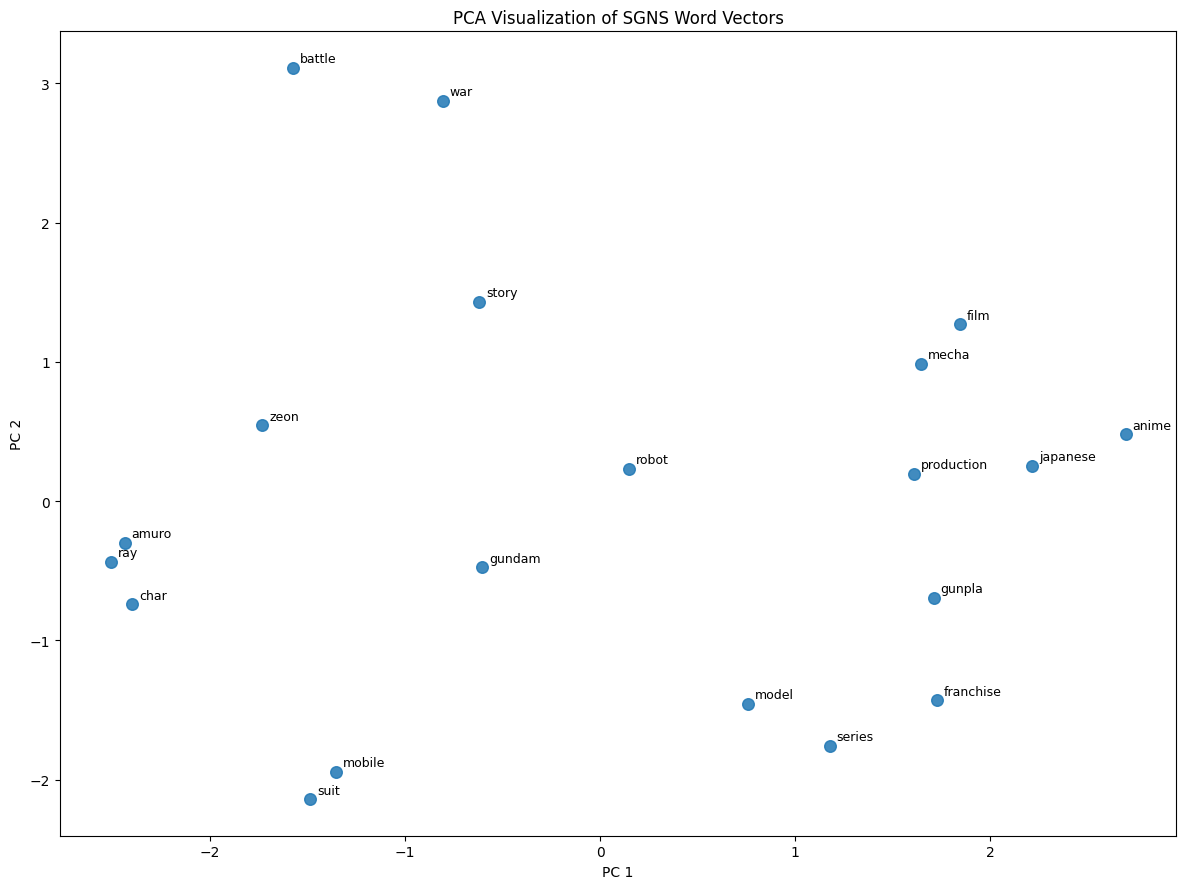

Saved PCA plot to: pca_skipgram_window5.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

viz_model = Word2Vec.load("exercise_5_skipgram_sgns.model")

candidate_words = [
    "gundam", "mobile", "suit", "amuro", "zeon", "char", "ray", "anime",
    "series", "film", "gunpla", "battle", "robot", "mecha", "war", "model",
    "franchise", "production", "japanese", "story", "tv", "episode", "creator",
    "director", "bandai", "manga", "toy", "game", "build", "design",
    "pilots", "saga", "victory", "unicorn", "seed", "destiny"
]

known_words = []
seen = set()
for word in candidate_words:
    if word in viz_model.wv.key_to_index and word not in seen:
        known_words.append(word)
        seen.add(word)

for word in viz_model.wv.index_to_key:
    if len(known_words) >= 20:
        break
    if word not in seen:
        known_words.append(word)
        seen.add(word)

known_words = known_words[:20]
print("Words used for PCA:", known_words)

vectors = np.array([viz_model.wv[word] for word in known_words])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 9))
plt.scatter(coords[:, 0], coords[:, 1], s=70, alpha=0.85)
for i, word in enumerate(known_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), textcoords="offset points", xytext=(5, 4), fontsize=9)
plt.title("PCA Visualization of SGNS Word Vectors")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()

png_path = "pca_skipgram_window5.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved PCA plot to: {png_path}")